<a href="https://colab.research.google.com/github/ettatanuja-cmyk/Neuro-exercise/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install KaggleHub so we can access Kaggle datasets directly
!pip install -q kagglehub

In [ ]:
# Import KaggleHub
import kagglehub

# Download the Fashion-MNIST dataset directly from Kaggle
dataset_path = kagglehub.dataset_download(
    "zalando-research/fashionmnist"
)

# Display the location where the dataset was downloaded
print("Dataset downloaded successfully!")
print("Dataset path:", dataset_path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Dataset downloaded successfully!
Dataset path: /kaggle/input/fashionmnist


In [ ]:
# Import os to work with files and folders
import os

# Display all files inside the downloaded dataset folder
print("Files in dataset:")
print(os.listdir(dataset_path))

Files in dataset:
['t10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv', 'fashion-mnist_train.csv', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte']


In [ ]:
# Numerical operations
import numpy as np

# Data handling
import pandas as pd

# Plotting images and graphs
import matplotlib.pyplot as plt

# Machine learning split
from sklearn.model_selection import train_test_split

# TensorFlow
import tensorflow as tf

# Keras layers and model
from tensorflow.keras import layers, models

In [ ]:
# Create the complete path for the training CSV
train_path = os.path.join(
    dataset_path,
    "fashion-mnist_train.csv"
)

# Create the complete path for the testing CSV
test_path = os.path.join(
    dataset_path,
    "fashion-mnist_test.csv"
)

# Read the training CSV
train_df = pd.read_csv(train_path)

# Read the testing CSV
test_df = pd.read_csv(test_path)

# Display dataset sizes
print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (60000, 785)
Testing data shape: (10000, 785)


In [ ]:
# Separate the target label from the pixel values
y_train = train_df["label"].values
y_test = test_df["label"].values

# Remove the label column to keep only pixel values
X_train = train_df.drop("label", axis=1).values
X_test = test_df.drop("label", axis=1).values

# Display shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (60000, 784)
y_train: (60000,)
X_test: (10000, 784)
y_test: (10000,)


In [ ]:
# Convert pixel values from 0–255 to 0–1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Check the new range
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
# Convert 784 flattened pixels into a 28×28 grayscale image
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Display the new shape
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)


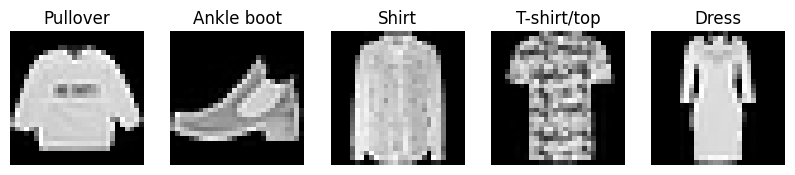

In [ ]:
# Class names of Fashion-MNIST
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Display 5 sample images
plt.figure(figsize=(10, 3))

for i in range(5):
    # Create a separate position for each image
    plt.subplot(1, 5, i + 1)

    # Display the image
    plt.imshow(X_train[i].squeeze(), cmap="gray")

    # Display its class name
    plt.title(class_names[y_train[i]])

    # Hide axis numbers
    plt.axis("off")

plt.show()

In [ ]:
# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# Display the sizes
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 48000
Validation samples: 12000
Testing samples: 10000


In [ ]:
# Number of filters in each convolutional layer
FILTERS_1 = 32
FILTERS_2 = 64
FILTERS_3 = 128

# Size of the convolution kernel
KERNEL_SIZE = (3, 3)

# Size of the max-pooling window
POOL_SIZE = (2, 2)

# Number of neurons in the dense layer
DENSE_UNITS = 128

# Dropout percentage
DROPOUT_RATE = 0.5

# Number of training cycles
EPOCHS = 5

# Number of images processed at one time
BATCH_SIZE = 64

In [ ]:
# Create the CNN model
model = models.Sequential([

    # First convolutional layer
    layers.Conv2D(
        FILTERS_1,
        KERNEL_SIZE,
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    # First max-pooling layer
    layers.MaxPooling2D(POOL_SIZE),

    # Second convolutional layer
    layers.Conv2D(
        FILTERS_2,
        KERNEL_SIZE,
        activation="relu"
    ),

    # Second max-pooling layer
    layers.MaxPooling2D(POOL_SIZE),

    # Third convolutional layer
    layers.Conv2D(
        FILTERS_3,
        KERNEL_SIZE,
        activation="relu"
    ),

    # Third max-pooling layer
    layers.MaxPooling2D(POOL_SIZE),

    # Convert feature maps into one vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(
        DENSE_UNITS,
        activation="relu"
    ),

    # Reduce overfitting
    layers.Dropout(DROPOUT_RATE),

    # Final layer: 10 Fashion-MNIST classes
    layers.Dense(
        10,
        activation="softmax"
    )
])

# Display the CNN architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Configure how the CNN learns
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display confirmation
print("CNN compiled successfully!")

CNN compiled successfully!


In [ ]:
# Train the CNN using the training data
history = model.fit(
    X_train,
    y_train,

    # Validation data used to check performance
    validation_data=(X_val, y_val),

    # Number of complete passes through the dataset
    epochs=EPOCHS,

    # Number of images processed at once
    batch_size=BATCH_SIZE
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 79ms/step - accuracy: 0.7250 - loss: 0.7549 - val_accuracy: 0.8112 - val_loss: 0.5098
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 77s 73ms/step - accuracy: 0.8209 - loss: 0.5038 - val_accuracy: 0.8443 - val_loss: 0.4260
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 76s 66ms/step - accuracy: 0.8442 - loss: 0.4322 - val_accuracy: 0.8665 - val_loss: 0.3711
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - accuracy: 0.8578 - loss: 0.3925 - val_accuracy: 0.8674 - val_loss: 0.3674
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 65ms/step - accuracy: 0.8709 - loss: 0.3589 - val_accuracy: 0.8786 - val_loss: 0.3352


In [ ]:
# Test the trained CNN on unseen test images
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

# Display final results
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8802 - loss: 0.3210
Test Loss: 0.32100313901901245
Test Accuracy: 0.8802000284194946


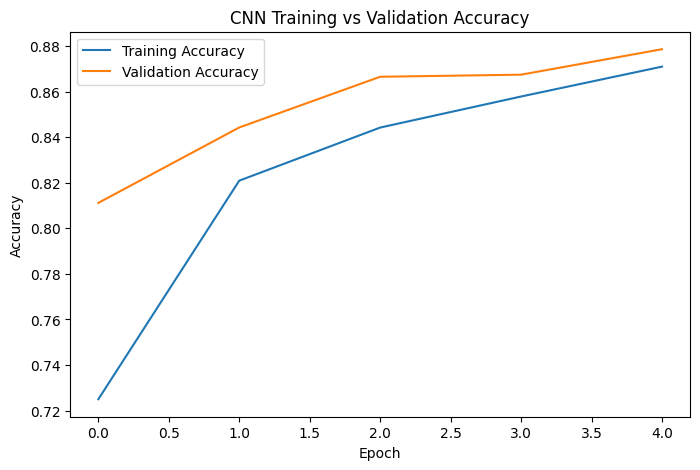

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()

plt.show()

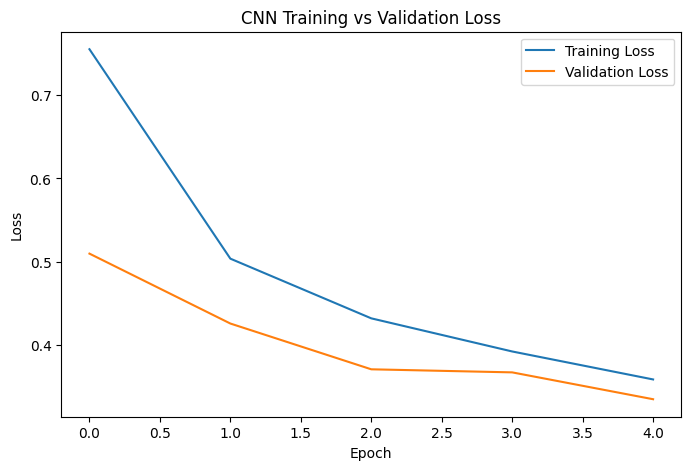

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
# Select the first 10 test images
sample_images = X_test[:10]

# Ask the CNN to predict their classes
predictions = model.predict(sample_images)

# Convert probability outputs into class numbers
predicted_classes = np.argmax(predictions, axis=1)

# Display predictions
for i in range(10):
    print(
        "Actual:",
        class_names[y_test[i]],
        "| Predicted:",
        class_names[predicted_classes[i]]
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Actual: T-shirt/top | Predicted: T-shirt/top
Actual: Trouser | Predicted: Trouser
Actual: Pullover | Predicted: Pullover
Actual: Pullover | Predicted: Shirt
Actual: Dress | Predicted: Dress
Actual: Pullover | Predicted: Shirt
Actual: Bag | Predicted: Bag
Actual: Shirt | Predicted: Pullover
Actual: Sandal | Predicted: Sandal
Actual: T-shirt/top | Predicted: T-shirt/top


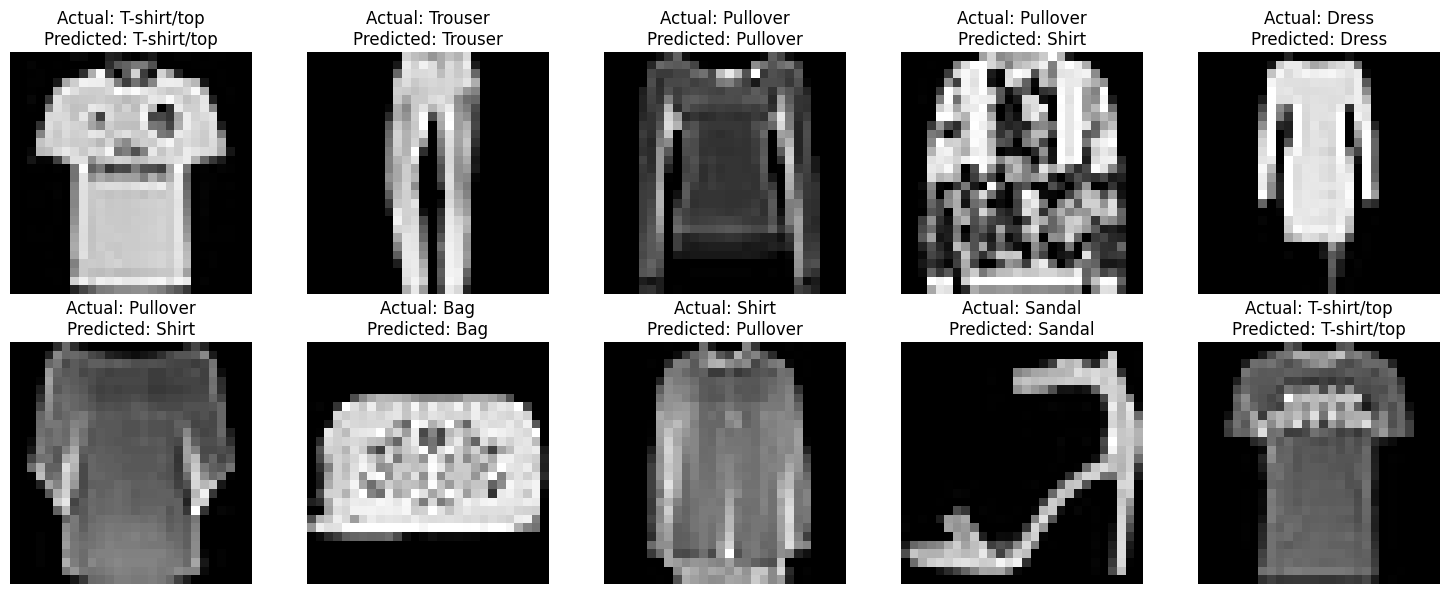

In [ ]:
# Display the first 10 test images with predictions
plt.figure(figsize=(15, 6))

for i in range(10):
    # Create image position
    plt.subplot(2, 5, i + 1)

    # Display image
    plt.imshow(X_test[i].squeeze(), cmap="gray")

    # Display actual and predicted labels
    plt.title(
        f"Actual: {class_names[y_test[i]]}\n"
        f"Predicted: {class_names[predicted_classes[i]]}"
    )

    # Hide axis
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Select one test image
image_index = 0

# Display the probability for all 10 classes
print("Prediction probabilities:")

for i in range(10):
    print(
        class_names[i],
        ":",
        round(predictions[image_index][i], 4)
    )

# Display the final predicted class
print("\nFinal prediction:")
print(class_names[predicted_classes[image_index]])

Prediction probabilities:
T-shirt/top : 0.919
Trouser : 0.0
Pullover : 0.0017
Dress : 0.0029
Coat : 0.0
Sandal : 0.0
Shirt : 0.0763
Sneaker : 0.0
Bag : 1e-04
Ankle boot : 0.0

Final prediction:
T-shirt/top


```mermaid
flowchart TD
    A[Kaggle Fashion-MNIST] --> B[KaggleHub]
    B --> C[Load CSV Dataset]
    C --> D[Separate Labels and Pixels]
    D --> E[Normalize 0-255 to 0-1]
    E --> F[Reshape 784 to 28x28x1]

    F --> G[Conv2D - 32 Filters]
    G --> H[Max Pooling]
    H --> I[Conv2D - 64 Filters]
    I --> J[Max Pooling]
    J --> K[Conv2D - 128 Filters]
    K --> L[Max Pooling]

    L --> M[Flatten]
    M --> N[Dense - 128 Neurons]
    N --> O[Dropout]
    O --> P[Softmax - 10 Classes]
    P --> Q[Prediction]
    
    Q --> R[Calculate Loss]
    R --> S[Backpropagation]
    S --> T[Update Weights and Kernels]
    T --> U[Trained CNN Model]